# Capítulo 3 — Regression & Model Assessment

Siguiendo [dmol.pub/ml/regression.html](https://dmol.pub/ml/regression.html).

Entorno: kernel `Python (dmol)`. Datos ya descargados en `../data/`.

## 3.1 De qué va este capítulo

**Regresión** = aprendizaje supervisado cuando la label es un **número real**: una solubilidad, una
energía, un pKa. Si la label fuera una categoría (tóxico / no tóxico) sería **clasificación**, que es
el capítulo 4. Lo que hicimos en el capítulo 2 ya era regresión; solo que no le pusimos nombre.

¿Qué añade entonces este capítulo? Una pregunta que dejamos abierta a propósito:

> **Todo el RMSE = 1.658 del capítulo 2 se midió sobre las mismas moléculas con las que se entrenó
> el modelo.**

Es como evaluar a un alumno con los mismos ejercicios que ha visto resueltos en clase: la nota dice
poco de si sabe la materia. El modelo lo queremos para moléculas **que no ha visto nunca**, y eso es
lo que hay que medir. Este capítulo va de cómo hacerlo bien, y de las muchas formas de hacerlo mal.

### Lo que el libro da por sabido

Dos conceptos de probabilidad que se usan en 3.4 (sesgo y varianza). Aquí van en corto y los
retomaremos allí:

| Concepto | Fórmula | En cristiano |
|---|---|---|
| **Esperanza** $E[x]$ | $\sum_x P(x)\,x$ | la media "a la larga": cada valor posible, pesado por su probabilidad |
| **Varianza** | $E\left[(x - E[x])^2\right]$ | la media de la distancia al cuadrado a la media: cuánto se dispersa. Su raíz es la desviación típica |

Analogía de laboratorio: si repites una valoración 100 veces, $E[x]$ es el valor al que tiende la
media de tus réplicas y la varianza mide cuánto bailan de una réplica a otra.

### Objetivos del capítulo, según el libro

1. Hacer regresión con muchas features usando una función de pérdida — *hecho en el capítulo 2*.
2. Entender el *batching* — *hecho en 2.3.7*.
3. Razonar sobre cómo partir los datos para evaluar.
4. Entender el **sesgo** y la **varianza** de un modelo.
5. Evaluar si un modelo **generaliza**, es decir, si funciona con datos que no ha visto.

Los dos primeros ya los tenemos. Lo nuevo son el 3, el 4 y el 5.

### Imports

Los mismos del capítulo 2, más uno nuevo:

| Import | Qué es | Para qué aquí |
|---|---|---|
| `pandas as pd` | tablas | cargar el CSV y partirlo |
| `numpy as np` | arrays y álgebra lineal | números aleatorios, mínimos cuadrados |
| `matplotlib.pyplot as plt` | gráficas | curvas de pérdida, parity plots |
| `jax`, `jax.numpy as jnp` | numpy que sabe derivar | descenso de gradiente, como en 2.3.6 |
| `rdkit.Chem`, `rdkit.Chem.Draw` | quimioinformática | leer y dibujar moléculas |
| **`MurckoScaffold`** | **nuevo.** Extrae el *esqueleto de Bemis–Murcko* de una molécula: los anillos y las cadenas que los unen, sin sustituyentes | los *scaffold splits* de 3.8.2 |

Diferencias con el código del libro:
- No hacemos `import dmol` (solo aplica el estilo de gráficas del libro).
- Leemos el CSV local en vez de descargarlo.
- El libro también importa `jax.example_libraries.optimizers`, pero ninguna celda del capítulo lo
  usa. Lo omitimos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import rdkit
import rdkit.Chem
import rdkit.Chem.Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

soldata = pd.read_csv("../data/curated-solubility-dataset.csv")
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

print(f"{len(soldata)} moléculas, {len(feature_names)} features")

9982 moléculas, 17 features


---

## 3.2 Overfitting

### El ruido: por qué los datos nunca encajan perfectos

En el capítulo 2 escribíamos la relación entre features y label como $y = f(\vec{x})$. La realidad es:

$$y = f(\vec{x}) + \epsilon$$

$\epsilon$ (épsilon) es el **ruido**: todo lo que mueve la solubilidad medida y **no** está en los 17
descriptores.

- **Error de medida.** La misma molécula medida en dos laboratorios no da lo mismo. En el
  ejercicio 10 vimos que las fuentes (`Group`) tienen sesgos propios.
- **Factores que no están en las features.** El polimorfo del sólido, la pureza, la temperatura
  real, el pH… Nada de eso aparece en `MolLogP` ni en `TPSA`.

Se supone que $\epsilon$ tiene **media 0** (no empuja siempre hacia el mismo lado) y una desviación
típica $\sigma$ **desconocida**.

La clave: el ruido es, por definición, **impredecible a partir de $\vec{x}$**. Un modelo que
"aprende" el ruido de sus datos de entrenamiento está aprendiendo algo que no se va a repetir en
moléculas nuevas. Eso es el **overfitting** (sobreajuste), y el experimento que viene lo provoca a
propósito.

### El montaje: 50 moléculas, 25 para entrenar y 25 para examinar

El libro coge **50 moléculas al azar** y las parte en dos mitades:

| Conjunto | Para qué |
|---|---|
| **Train** (entrenamiento) | el modelo lo ve: con estas moléculas se calculan los gradientes |
| **Test** (prueba) | el modelo **nunca** lo ve durante el entrenamiento. Solo sirve para medir |

¿Por qué solo 50 teniendo 9982? **Para provocar el problema.** El modelo tiene 18 parámetros
(17 pesos + el bias) y solo 25 moléculas para ajustarlos. Con tan poca información le resulta fácil
ajustarse a los caprichos de esas 25 moléculas concretas.

Tres detalles del código:

1. **`sample(50, replace=False, random_state=4)`** saca 50 filas al azar sin repetir. `random_state`
   es la **semilla**: fija la secuencia de números aleatorios, así cada ejecución saca las mismas 50.
   El libro no pone semilla, así que a cada lector le tocan moléculas distintas; nosotros la fijamos
   para que las cifras del texto coincidan con las de las celdas. Escogí la 4 porque su resultado queda
   en el centro de las semillas 0–7 (la 5.ª de 8, ordenadas por error en test) (al final de la sección están las 8, para que se vea que no es
   un caso escogido a dedo).
2. **`.copy()`** hace de `train` y `test` tablas independientes: modificarlas no toca `soldata`.
3. **Se estandariza con la media y la desviación del train, también el test.** Es el aviso de
   *data leakage* de 2.3.8, ahora en serio. Si calcularas la media con las 50 moléculas, las 25 de
   test influirían en cómo se preparan los datos de entrenamiento: el examen asomando por los apuntes.
   Y en la vida real las moléculas nuevas llegan de una en una, así que no existe una "media del
   test": se transforman con los números que ya tenías. El libro hace lo mismo con `-=` y `/=`;
   nosotros guardamos `train_mean` y `train_std` en variables para que se vea qué se reutiliza.

In [2]:
sample = soldata.sample(50, replace=False, random_state=4)
train = sample[:25].copy()
test = sample[25:].copy()

# media y desviación SOLO del train; se aplican a los dos conjuntos
train_mean = train[feature_names].mean()
train_std = train[feature_names].std()
train[feature_names] = (train[feature_names] - train_mean) / train_std
test[feature_names] = (test[feature_names] - train_mean) / train_std

x = train[feature_names].values
y = train["Solubility"].values
test_x = test[feature_names].values
test_y = test["Solubility"].values

print("train:", x.shape, "   test:", test_x.shape)
print(f"solubilidad media   train {y.mean():.2f}   test {test_y.mean():.2f}")
print(f"desviación típica   train {y.std():.2f}   test {test_y.std():.2f}")
print()
print(f"train: media de las features, en valor absoluto, como mucho {np.abs(x.mean(axis=0)).max():.1e}")
print(f"test:  valores de las features entre {test_x.min():+.1f} y {test_x.max():+.1f} desviaciones del train")

# ¿qué molécula de test está más lejos de lo que el train conoce?
col = np.abs(test_x).max(axis=0).argmax()
fila = np.abs(test_x[:, col]).argmax()
nombre_col = feature_names[col]
print()
print(f"la más extrema: {test['Name'].iloc[fila]}")
print(f"  {nombre_col} = {sample[nombre_col].iloc[25 + fila]:.0f}  →  {test_x[fila, col]:+.1f} desviaciones")
print(f"  en las 25 de train, {nombre_col} va de {sample[nombre_col].iloc[:25].min():.0f} a {sample[nombre_col].iloc[:25].max():.0f}")

train: (25, 17)    test: (25, 17)
solubilidad media   train -3.11   test -2.98
desviación típica   train 2.43   test 2.85

train: media de las features, en valor absoluto, como mucho 4.3e-16
test:  valores de las features entre -4.1 y +8.9 desviaciones del train

la más extrema: raffinose
  NumHDonors = 11  →  +8.9 desviaciones
  en las 25 de train, NumHDonors va de 0 a 4


Cómo se lee:

- **Las dos mitades no son iguales.** Train tiene solubilidad media −3.11 y desviación 2.43; test,
  −2.98 y 2.85. Con 25 moléculas basta el azar para que un conjunto salga más disperso que el otro.
- **En train, la media de cada feature queda en 0** (4·10⁻¹⁶ es cero más el error de redondeo del
  ordenador). En test no: sus features van de −4.1 a +8.9 desviaciones. Es lo esperable, porque se
  han estandarizado con números que no son los suyos.
- **La rafinosa**, un trisacárido, tiene 11 dadores de puente de hidrógeno (sus OH). Entre las 25
  moléculas de train, la que más tiene llega a 4. El modelo tendrá que predecir una molécula que
  está **8.9 desviaciones** fuera de todo lo que ha visto. Apúntala, que vuelve a salir.

### La pérdida y un punto de partida aleatorio

La pérdida es el mismo MSE del capítulo 2, con una novedad: **`@jax.jit`**.

- Una línea con `@` encima de un `def` es un **decorador**: envuelve la función en otra que le añade
  comportamiento. Aquí el comportamiento es `jax.jit`.
- **JIT** = *just-in-time compilation*. La primera vez que llamas a `loss`, JAX traduce la función a
  código máquina optimizado para esas formas de array; las siguientes llamadas usan directamente la
  versión compilada. Vamos a llamarla 4000 veces (train y test en cada paso), así que compensa.
- No cambia **qué** se calcula, solo lo rápido que va.

Los pesos iniciales ya no son ceros sino **números aleatorios** sacados de una normal de media 0 y
desviación 1. Con features estandarizadas es una escala razonable, y es como se inicializan las redes
neuronales del capítulo 6. También aquí fijamos la semilla (`np.random.default_rng(4)`); el libro usa
`np.random.normal` sin semilla.

In [3]:
@jax.jit
def loss(w, b, x, y):
    return jnp.mean((y - jnp.dot(x, w) - b) ** 2)


loss_grad = jax.grad(loss, (0, 1))

rng = np.random.default_rng(4)
w = rng.normal(size=x.shape[1])   # 17 pesos aleatorios
b = 0.0

print("pesos iniciales:", w.round(2))
print(f"pérdida inicial   train {loss(w, b, x, y):.2f}   test {loss(w, b, test_x, test_y):.2f}")

pesos iniciales: [-0.65 -0.17  1.66  0.66 -1.64 -0.01 -0.62  0.15 -1.61  0.24  0.24  1.58
  0.32  0.51 -1.49  2.25 -1.92]


pérdida inicial   train 30.73   test 59.04


### Entrenar vigilando las dos pérdidas

El bucle es el descenso de gradiente de 2.3.6, con $\eta = 0.05$ y 2000 pasos. Lo nuevo es que en
**cada paso** apuntamos dos números:

- **pérdida de train**: la que el algoritmo está minimizando;
- **pérdida de test**: la calculamos solo para mirarla. Fíjate en el código: `loss_grad` recibe
  `x, y` y **nunca** `test_x, test_y`. El test no mueve ningún peso.

El eje vertical va en **escala logarítmica** (`set_yscale("log")`): cada marca vale 10 veces la
anterior. Hace falta porque la pérdida pasa de ~20 a menos de 1, y en escala lineal toda la parte
interesante quedaría aplastada contra el suelo.

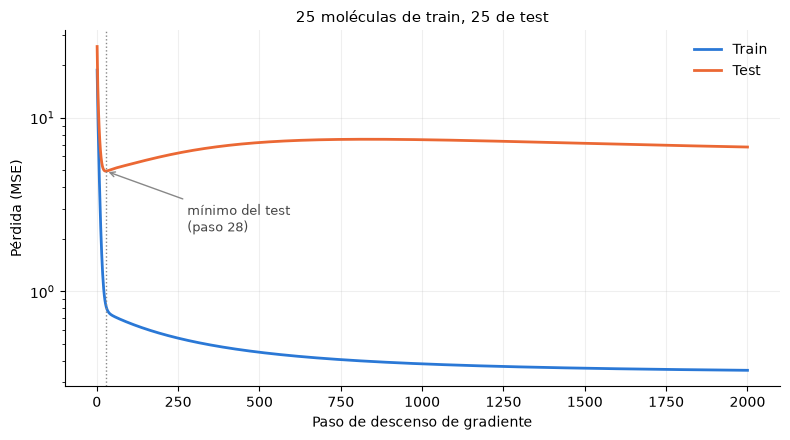

  paso  loss train  loss test  RMSE train  RMSE test
     1      18.774     25.663       4.333      5.066
    10       3.112      6.958       1.764      2.638
    28       0.829      4.925       0.910      2.219
   100       0.658      5.381       0.811      2.320
   500       0.447      7.195       0.669      2.682
  2000       0.352      6.777       0.593      2.603

mínimo del test en el paso 28; máximo posterior en el paso 833 (loss 7.51)
al final, la pérdida de test es 19.3 veces la de train


In [4]:
loss_progress = []
test_loss_progress = []
eta = 0.05
for i in range(2000):
    grad = loss_grad(w, b, x, y)
    w -= eta * grad[0]
    b -= eta * grad[1]
    loss_progress.append(float(loss(w, b, x, y)))
    test_loss_progress.append(float(loss(w, b, test_x, test_y)))

loss_progress = np.array(loss_progress)
test_loss_progress = np.array(test_loss_progress)
pasos = np.arange(1, len(loss_progress) + 1)
paso_min = int(test_loss_progress.argmin()) + 1          # contando desde 1
pico = paso_min + int(test_loss_progress[paso_min:].argmax()) + 1

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(pasos, loss_progress, color="#2a78d6", linewidth=2, label="Train")
ax.plot(pasos, test_loss_progress, color="#eb6834", linewidth=2, label="Test")
ax.axvline(paso_min, color="#888", linestyle=":", linewidth=1)
ax.annotate(f"mínimo del test\n(paso {paso_min})",
            xy=(paso_min, test_loss_progress[paso_min - 1]),
            xytext=(paso_min + 250, test_loss_progress[paso_min - 1] * 0.45),
            fontsize=9, color="#444", arrowprops=dict(arrowstyle="->", color="#888"))
ax.set_yscale("log")
ax.set_xlabel("Paso de descenso de gradiente")
ax.set_ylabel("Pérdida (MSE)")
ax.set_title("25 moléculas de train, 25 de test", fontsize=11)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/03_curva_overfitting.png", dpi=150)
plt.show()

print(f"{'paso':>6s} {'loss train':>11s} {'loss test':>10s} {'RMSE train':>11s} {'RMSE test':>10s}")
for p in sorted({1, 10, paso_min, 100, 500, 2000}):
    lt, le = loss_progress[p - 1], test_loss_progress[p - 1]
    print(f"{p:6d} {lt:11.3f} {le:10.3f} {np.sqrt(lt):11.3f} {np.sqrt(le):10.3f}")
print()
print(f"mínimo del test en el paso {paso_min}; máximo posterior en el paso {pico} (loss {test_loss_progress[pico - 1]:.2f})")
print(f"al final, la pérdida de test es {test_loss_progress[-1] / loss_progress[-1]:.1f} veces la de train")

La curva tiene dos fases, separadas por la línea de puntos:

| Paso | Loss train | Loss test | Qué pasa |
|---|---|---|---|
| 1 | 18.77 | 25.66 | punto de partida (pesos aleatorios) |
| 10 | 3.11 | 6.96 | las dos bajan juntas |
| **28** | **0.83** | **4.93** | **mínimo del test** |
| 100 | 0.66 | 5.38 | train sigue bajando; test ya sube |
| 500 | 0.45 | 7.20 | |
| 2000 | 0.35 | 6.78 | |

1. **Pasos 1 a 28: aprende de verdad.** Las dos pérdidas caen a la vez. Lo que el modelo saca de las
   25 moléculas de train también sirve para las otras 25, así que es química que se generaliza:
   lipofilia, tamaño, polaridad.
2. **Del paso 28 en adelante: memoriza.** La pérdida de train sigue bajando (0.83 → 0.35), pero la de
   test **sube**, hasta 7.51 en el paso 833, y luego baja un poco hasta 6.78. Lo que el modelo ajusta
   ahora son las particularidades de esas 25 moléculas concretas —su ruido—, y eso no le sirve para
   ninguna otra.

Al final, la pérdida de test es **19 veces** la de train. Esa brecha entre las dos curvas es la firma
del overfitting. Y fíjate en que, si solo hubiéramos mirado la curva azul, diríamos que el
entrenamiento va de maravilla: **la pérdida de train no avisa de nada**.

Una consecuencia práctica: parando en el paso 28 tendríamos el mejor modelo para moléculas nuevas.
Eso tiene nombre, *early stopping* (parada temprana), y es una técnica estándar en redes neuronales.
Pero hay una trampa: para saber que el mejor paso es el 28 hemos **mirado el test**, y un test que
se usa para tomar decisiones deja de ser un examen limpio. La solución habitual es apartar un tercer
conjunto, el de **validación**, solo para esas decisiones.

### Parity plots: train frente a test

El parity plot de 2.3.9 (real en el eje X, predicho en el eje Y, perfecto = sobre la diagonal), ahora
con el modelo del paso 2000 y en dos paneles: las 25 moléculas que el modelo ha visto y las 25 que no.

En cada panel, el **RMSE** y la **correlación** $r$ entre real y predicho. El libro rotula ese primer
número como `loss`, pero calcula la raíz: es el RMSE. Y para tener un listón, imprimimos también el
RMSE del modelo tonto de 2.3.5, "predecir siempre la media", usando la media **del train** (la única
que el modelo conoce).

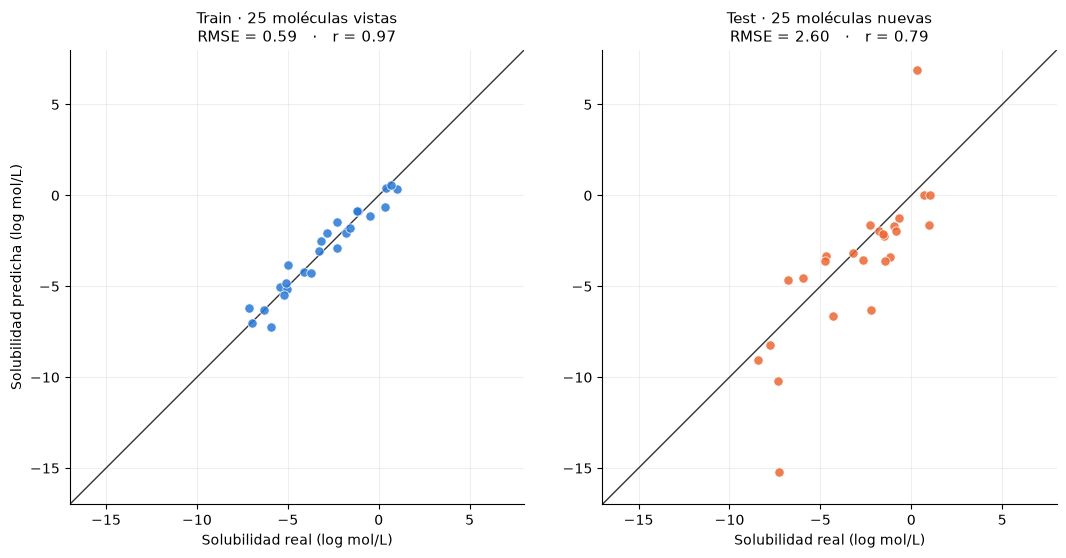

train  RMSE modelo 0.593   RMSE 'predecir la media' 2.426   r 0.970
test   RMSE modelo 2.603   RMSE 'predecir la media' 2.854   r 0.793

test: real entre -8.42 y 1.01;  predicho entre -15.20 y 6.92

los 3 peores del test:
  4-chloro-N-(5-chloro-2-methylphenyl)-3-[(E)-2 real  -7.26   predicho -15.20   error 7.93
  raffinose                                     real   0.30   predicho   6.92   error 6.62
  oxaprozin;  4,5-diphenyl-2-oxazolepropanoic a real  -2.24   predicho  -6.29   error 4.05

RMSE test quitando solo la peor: 2.107


In [5]:
yhat = x @ w + b
test_yhat = test_x @ w + b


def rmse_y_r(real, pred):
    return np.sqrt(np.mean((real - pred) ** 2)), np.corrcoef(real, pred)[0, 1]


todos = np.concatenate([y, yhat, test_y, test_yhat])
lims = (np.floor(todos.min()) - 1, np.ceil(todos.max()) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
paneles = [(axes[0], y, yhat, "Train · 25 moléculas vistas", "#2a78d6"),
           (axes[1], test_y, test_yhat, "Test · 25 moléculas nuevas", "#eb6834")]
for ax, real, pred, titulo, color in paneles:
    rmse, r = rmse_y_r(real, pred)
    ax.plot(lims, lims, color="#333", linewidth=1)
    ax.scatter(real, pred, s=45, color=color, alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_title(f"{titulo}\nRMSE = {rmse:.2f}   ·   r = {r:.2f}", fontsize=11)
    ax.set_xlabel("Solubilidad real (log mol/L)")
    ax.grid(alpha=0.2)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("Solubilidad predicha (log mol/L)")
fig.tight_layout()
fig.savefig("../figuras/03_parity_train_test.png", dpi=150)
plt.show()

media_train = y.mean()
for nombre, real, pred in [("train", y, yhat), ("test", test_y, test_yhat)]:
    rmse, r = rmse_y_r(real, pred)
    rmse_media = np.sqrt(np.mean((real - media_train) ** 2))
    print(f"{nombre:5s}  RMSE modelo {rmse:.3f}   RMSE 'predecir la media' {rmse_media:.3f}   r {r:.3f}")

print(f"\ntest: real entre {test_y.min():.2f} y {test_y.max():.2f};  predicho entre {test_yhat.min():.2f} y {test_yhat.max():.2f}")

errores = np.abs(test_yhat - test_y)
print("\nlos 3 peores del test:")
for i in np.argsort(errores)[::-1][:3]:
    print(f"  {test['Name'].iloc[i][:45]:45s} real {test_y[i]:6.2f}   predicho {test_yhat[i]:6.2f}   error {errores[i]:.2f}")
sin_peor = np.arange(len(test_y)) != errores.argmax()
print(f"\nRMSE test quitando solo la peor: {np.sqrt(np.mean(errores[sin_peor] ** 2)):.3f}")

Los dos paneles, en números:

| | RMSE modelo | RMSE "predecir la media" | $r$ |
|---|---|---|---|
| **Train** | 0.59 | 2.43 | 0.97 |
| **Test** | 2.60 | 2.85 | 0.79 |

- **En train el modelo parece excelente**: puntos pegados a la diagonal, $r = 0.97$ y un error cuatro
  veces menor que el del modelo tonto.
- **En test esa ventaja casi desaparece**: 2.60 frente a 2.85, apenas un 9 % mejor que no mirar la
  molécula. Lo que parecía un gran modelo era, sobre todo, memoria.
- **Predicciones imposibles.** La rafinosa, con solubilidad real +0.30, recibe una predicción de
  **+6.92**: unos 8 millones de mol/L, cuando el agua pura tiene 55 mol/L. En el otro extremo, un
  pigmento bis-azoico con cuatro cloros (el nombre larguísimo; 917 g/mol) tiene −7.26 y recibe
  **−15.20**, más insoluble que cualquiera de las 9982 moléculas del dataset (la mínima era −13.17).
- **El RMSE lo dominan unos pocos.** Con quitar solo la peor molécula, el RMSE de test baja de 2.60 a
  2.11. El error va al cuadrado, así que dos o tres fallos gordos pesan más que veinte aciertos.
- **$r = 0.79$ no contradice lo anterior.** $r$ mide si el **orden** es correcto (insolubles abajo,
  solubles arriba), no si los valores tienen la escala buena. Las dos predicciones extremas van en la
  dirección correcta, pero exageradas: se alejan de la media del train unas tres veces más de lo que
  deberían.

#### ¿Por qué fallan justo esas? *(variante propia)*

La rafinosa ya la habíamos señalado como la molécula de test más alejada del train. La sospecha: los
fallos grandes se concentran en moléculas **fuera del rango** que el modelo conoce.

Para comprobarlo, marcamos una molécula de test como "fuera de rango" si **alguna** de sus 17
features queda por debajo del mínimo o por encima del máximo de esa feature en las 25 de train. Lo
hacemos con los valores sin estandarizar (`sample`); estandarizar no cambia qué queda fuera. Después
comparamos el RMSE de los dos grupos.

In [6]:
crudo_train = sample[:25][feature_names]
crudo_test = sample[25:][feature_names]
fuera = (crudo_test < crudo_train.min()) | (crudo_test > crudo_train.max())
n_fuera = fuera.sum(axis=1).values          # cuántas de las 17 features se salen, por molécula

diagnostico = pd.DataFrame({
    "molécula": test["Name"].str[:32].values,
    "error": errores,
    "features fuera de rango": n_fuera,
}).sort_values("error", ascending=False)
print(diagnostico.round(2).to_string(index=False))

dentro = n_fuera == 0
print()
print(f"{(~dentro).sum():2d} moléculas con alguna feature fuera de rango → RMSE {np.sqrt(np.mean(errores[~dentro] ** 2)):.3f}")
print(f"{dentro.sum():2d} moléculas dentro del rango del train      → RMSE {np.sqrt(np.mean(errores[dentro] ** 2)):.3f}")

                        molécula  error  features fuera de rango
4-chloro-N-(5-chloro-2-methylphe   7.93                       12
                       raffinose   6.62                        7
oxaprozin;  4,5-diphenyl-2-oxazo   4.05                        0
                   tetrafluthrin   2.88                        1
          2-chloropropionic acid   2.60                        0
3,3'-[[4-[(2-chloro-4-nitropheny   2.34                        2
N-(4-fluorophenyl)-2-hydroxy-N-p   2.23                        0
    5-oxo-3-phenyl-hexanoic acid   2.18                        0
               hexadecanoic acid   2.18                        0
                   pendimethalin   1.43                        1
                     bayer 15080   1.33                        0
                       kinoprene   1.09                        1
  2-methoxy-3,4-dihydro-2H-pyran   1.09                        0
        potassium cyanosulfanide   1.00                        4
3-methyl-2-propyl-2,3-dih

Confirmado, con matices:

- Las dos peores se salen del rango en **12** y **7** features. El pigmento (917 g/mol) es mucho más
  grande que cualquier molécula del train; la rafinosa tiene muchos más OH.
- Las 10 moléculas que se salen en algo tienen **RMSE 3.55**; las 15 que caen dentro, **1.70**. El doble.
- Pero no es una regla perfecta. La tercera peor (la oxaprozina, error 4.05) está **dentro** del rango
  en las 17 features. Y al revés: el formiato de metilo se sale en 6 y falla solo por 0.70.

Por qué un modelo lineal extrapola tan mal: la predicción es una suma de peso × feature, y una suma
no tiene freno. Si una feature vale 8.9 desviaciones en lugar de las 1–2 habituales, su término crece
en proporción, y nada en el modelo sabe que la solubilidad tiene un techo físico.

Esta idea —que un modelo solo es fiable dentro de la zona de datos que ha visto— tiene nombre:
**dominio de aplicabilidad**. El libro la trata en 3.8.

### Qué es, entonces, el overfitting

La definición del libro: el resultado de **entrenar demasiados pasos o con demasiados parámetros**,
de forma que el modelo **aprende el ruido** de los datos de entrenamiento.

La analogía del alumno que se aprende de memoria las soluciones de los 25 ejercicios resueltos: saca
un 10 en esos, y en el examen, con ejercicios nuevos, lo hace peor que uno que solo entendió la idea
general. Y lo hace peor precisamente porque aplica con toda confianza "reglas" que solo valían para
aquellos 25.

Por qué aquí era tan fácil:

| | Capítulo 2 | Este experimento |
|---|---|---|
| moléculas de entrenamiento | 9982 | 25 |
| parámetros | 18 | 18 |
| moléculas por parámetro | ~555 | ~1.4 |

Con 555 moléculas por parámetro, el ruido de unas se compensa con el de otras (media 0) y el modelo
solo puede quedarse con la tendencia común. Con 1.4, cada parámetro puede dedicarse a explicar el
capricho de un par de moléculas.

¿Significa esto que el 1.658 del capítulo 2 está a salvo? **Todavía no lo sabemos** — lo mediremos en
3.6. Y en 3.2.1 el libro separa con datos sintéticos los ingredientes que hacen falta para sobreajustar:
ruido, features de más o mal correlacionadas, y entrenar hasta converger.

### Variante propia: ¿ha sido cosa de la semilla?

*(No está en el libro.)*

Todo lo anterior sale de **un** sorteo de 50 moléculas. Con 25 datos, otro sorteo puede contar otra
historia. Repetimos el experimento completo con las semillas 0 a 7 (la misma semilla para elegir las
moléculas y para los pesos iniciales) y dibujamos cada uno en su panel.

Esto se llama *small multiples*: la misma gráfica repetida con los mismos ejes, un caso por panel,
para comparar formas de un vistazo sin amontonar 16 curvas en una.

`experimento(seed)` es exactamente el código de arriba metido en una función; con `seed=4` reproduce
la curva que ya hemos visto.

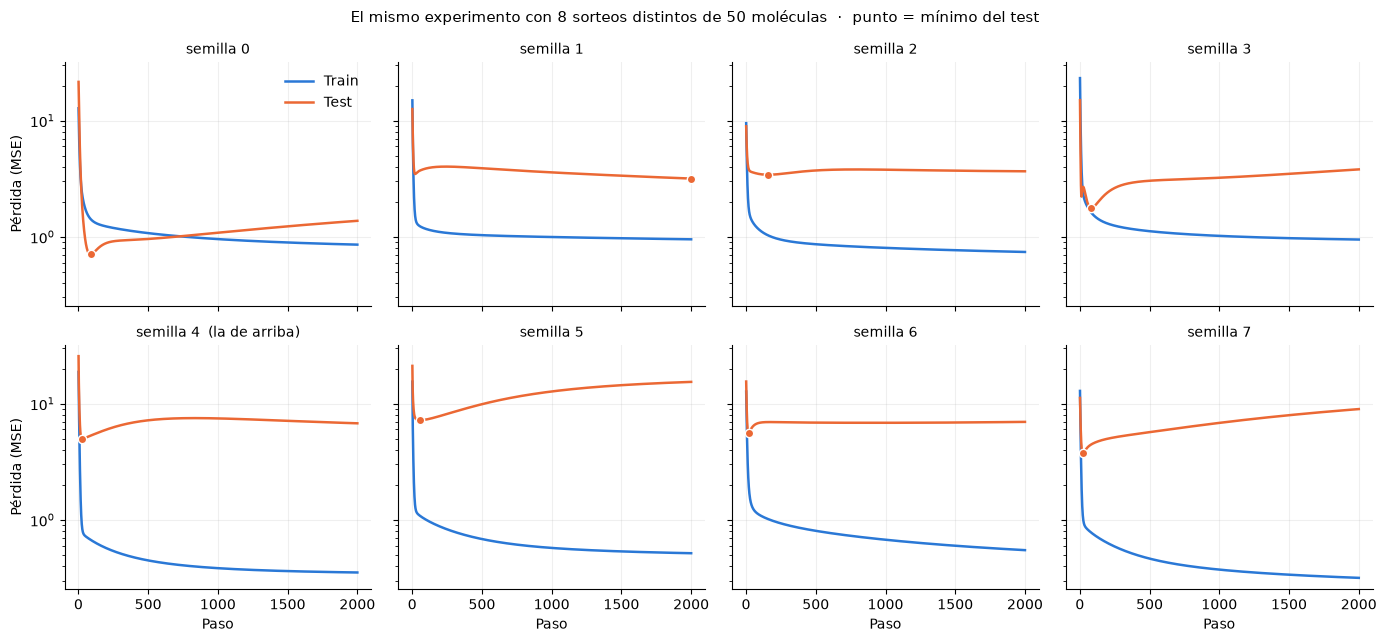

         paso mín. test  RMSE test mín.  RMSE train final  RMSE test final  RMSE 'predecir media' ¿test final peor que la media?
semilla                                                                                                                         
0                    87           0.839             0.925            1.171                  1.996                             no
1                  2000           1.780             0.975            1.780                  2.858                             no
2                   159           1.849             0.860            1.914                  3.034                             no
3                    83           1.332             0.973            1.950                  2.400                             no
4                    28           2.219             0.593            2.603                  2.854                             no
5                    59           2.686             0.718            3.925                  2.065

In [7]:
def experimento(seed, n_pasos=2000, eta=0.05):
    # Repite el montaje de 3.2 con otra semilla. Devuelve las dos curvas y el listón del test
    muestra = soldata.sample(50, replace=False, random_state=seed)
    tr, te = muestra[:25].copy(), muestra[25:].copy()
    media, desv = tr[feature_names].mean(), tr[feature_names].std()
    tr[feature_names] = (tr[feature_names] - media) / desv
    te[feature_names] = (te[feature_names] - media) / desv
    xs, ys = tr[feature_names].values, tr["Solubility"].values
    txs, tys = te[feature_names].values, te["Solubility"].values

    ws = np.random.default_rng(seed).normal(size=xs.shape[1])
    bs = 0.0
    curva_tr, curva_te = [], []
    for _ in range(n_pasos):
        g = loss_grad(ws, bs, xs, ys)
        ws -= eta * g[0]
        bs -= eta * g[1]
        curva_tr.append(float(loss(ws, bs, xs, ys)))
        curva_te.append(float(loss(ws, bs, txs, tys)))
    rmse_media = float(np.sqrt(np.mean((tys - ys.mean()) ** 2)))
    return np.array(curva_tr), np.array(curva_te), rmse_media


semillas = range(8)
resultados = {s: experimento(s) for s in semillas}

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), sharex=True, sharey=True)
filas = []
for ax, s in zip(axes.flat, semillas):
    c_tr, c_te, rmse_media = resultados[s]
    p_min = int(c_te.argmin()) + 1
    ax.plot(pasos, c_tr, color="#2a78d6", linewidth=1.8, label="Train")
    ax.plot(pasos, c_te, color="#eb6834", linewidth=1.8, label="Test")
    ax.plot(p_min, c_te[p_min - 1], "o", color="#eb6834", markersize=6, markeredgecolor="white")
    ax.set_yscale("log")
    ax.set_title(f"semilla {s}" + ("  (la de arriba)" if s == 4 else ""), fontsize=10)
    ax.grid(alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    filas.append({"semilla": s, "paso mín. test": p_min,
                  "RMSE test mín.": np.sqrt(c_te.min()),
                  "RMSE train final": np.sqrt(c_tr[-1]),
                  "RMSE test final": np.sqrt(c_te[-1]),
                  "RMSE 'predecir media'": rmse_media})
axes[0, 0].legend(frameon=False)
for ax in axes[1]:
    ax.set_xlabel("Paso")
for ax in axes[:, 0]:
    ax.set_ylabel("Pérdida (MSE)")
fig.suptitle("El mismo experimento con 8 sorteos distintos de 50 moléculas  ·  punto = mínimo del test", fontsize=11)
fig.tight_layout()
fig.savefig("../figuras/03_overfitting_semillas.png", dpi=150)
plt.show()

tabla = pd.DataFrame(filas).set_index("semilla")
tabla["¿test final peor que la media?"] = np.where(tabla["RMSE test final"] > tabla["RMSE 'predecir media'"], "sí", "no")
print(tabla.round(3).to_string())

Qué dicen los 8 paneles:

- **La brecha aparece en los 8.** Al final, el RMSE de test supera al de train en todos: el de train
  queda entre 0.56 y 0.98, el de test entre 1.17 y 3.93.
- **En 7 de 8, el test toca fondo pronto** (entre los pasos 18 y 159) y luego empeora. La excepción es
  la **semilla 1**: su test sube un poco al principio y después vuelve a bajar despacio, así que su
  mínimo es el último paso. En 2000 pasos, ese sorteo no llega a sobreajustar (aunque la brecha
  existe: 0.98 en train frente a 1.78 en test).
- **En 3 de 8 (semillas 5, 6 y 7), el modelo final es peor en test que predecir la media.** En la 6 y
  la 7, el modelo del mínimo sí batía a la media: los 2000 pasos han estropeado un modelo útil. La 5
  no la bate ni en su mejor paso (2.69 frente a 2.07).
- **La misma receta da resultados muy distintos.** El RMSE de test final va de 1.17 a 3.93 solo por
  cambiar qué 50 moléculas salieron. En la semilla 0 el test llega a 0.84, **por debajo** del train
  (0.93): a veces el examen sale fácil. Con 25 moléculas de test, **la propia medida del error es
  ruidosa**.

Ese último punto es el problema que resuelve la **validación cruzada** (3.6): no fiarse de un único
reparto train/test.

### Resumen de 3.1 y de la introducción de 3.2

- **Regresión** = aprendizaje supervisado con label real. Lo del capítulo 2 ya lo era.
- Las labels llevan **ruido**: $y = f(\vec{x}) + \epsilon$, con $\epsilon$ de media 0 e impredecible a
  partir de $\vec{x}$.
- **Train / test**: el test nunca entra en los gradientes, y se estandariza con la media y la
  desviación **del train**.
- **Firma del overfitting**: la pérdida de train sigue bajando mientras la de test sube. La de train,
  sola, no avisa.
- Con 25 moléculas y 18 parámetros: RMSE 0.59 en train y 2.60 en test, apenas mejor que predecir la
  media (2.85).
- Los peores fallos son **extrapolaciones**: moléculas fuera del rango del train (RMSE 3.55 frente a 1.70).
- Un único reparto de 25 moléculas mide el error con mucho ruido: entre 1.17 y 3.93 según el sorteo.

**Siguiente**: 3.2.1, overfitting con datos sintéticos. Con un polinomio conocido, el libro separa qué
hace falta para sobreajustar: ruido, features que sobran o están mal correlacionadas, y entrenar hasta
converger.